In [2]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("../data/processed/cicids2017_processed.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (2830743, 80)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6      

In [3]:
X = df.drop(columns=["Attack_Label", "Attack_Type"])
y = df["Attack_Label"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2830743, 78)
Label vector shape: (2830743,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (2264594, 78) (2264594,)
Test shape: (566149, 78) (566149,)


In [5]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
Attack_Label
0    0.803004
4    0.089256
7    0.056144
3    0.045227
2    0.004887
8    0.000770
1    0.000695
6    0.000013
5    0.000004
Name: proportion, dtype: float64

Test distribution:
Attack_Label
0    0.803004
4    0.089256
7    0.056144
3    0.045228
2    0.004887
8    0.000770
1    0.000694
6    0.000012
5    0.000004
Name: proportion, dtype: float64


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from pathlib import Path


In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced"
)


In [8]:
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10, n_jobs=-1,
                       random_state=42)

In [10]:
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.99      1.00    454620
           1       0.14      0.99      0.25       393
           2       1.00      1.00      1.00      2767
           3       1.00      1.00      1.00     25606
           4       0.99      1.00      1.00     50532
           5       1.00      1.00      1.00         2
           6       1.00      0.86      0.92         7
           7       0.99      1.00      1.00     31786
           8       0.93      0.97      0.95       436

    accuracy                           0.99    566149
   macro avg       0.90      0.98      0.90    566149
weighted avg       1.00      0.99      1.00    566149



In [11]:
MODEL_DIR = Path("../models/trained_models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "rf_ids_model.pkl"
joblib.dump(rf_model, model_path)

print("Model saved to:", model_path)


Model saved to: ..\models\trained_models\rf_ids_model.pkl


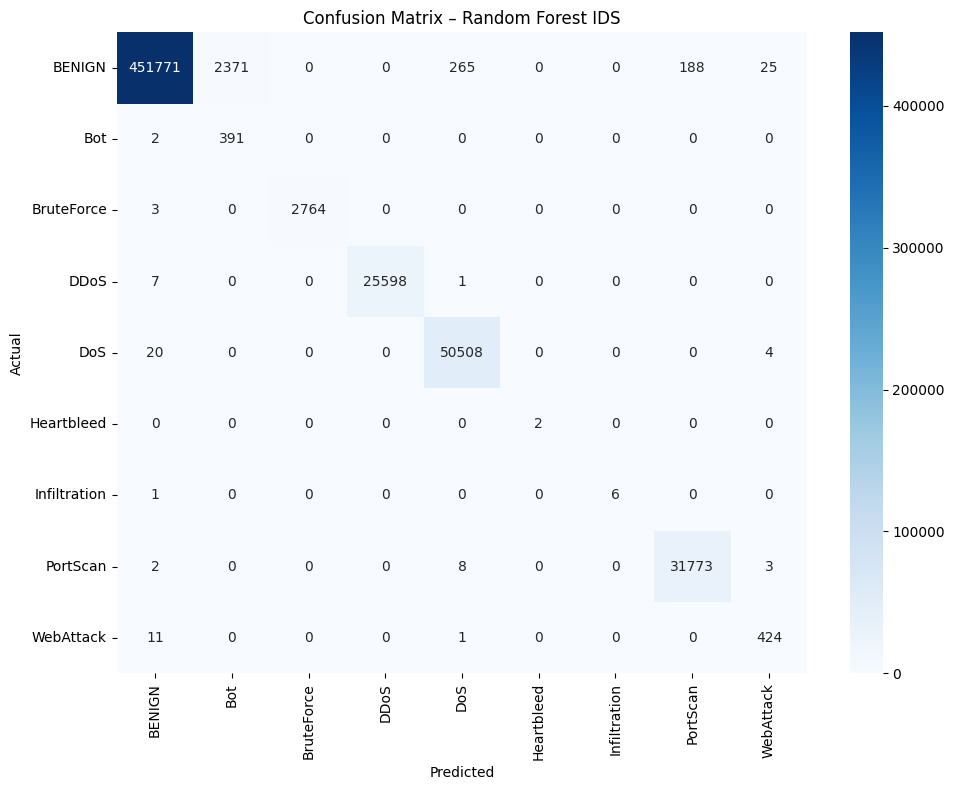

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

label_encoder = joblib.load("../models/label_encoder.pkl")
class_names = label_encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues",
    fmt="d",
    annot=True,
    norm=None
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest IDS")
plt.tight_layout()
plt.show()



In [13]:
# Take one sample from test set
sample_X = X_test.iloc[[0]]
sample_y = y_test.iloc[0]

print("True label (encoded):", sample_y)


True label (encoded): 4


In [14]:
loaded_model = joblib.load("../models/trained_models/rf_ids_model.pkl")
pred = loaded_model.predict(sample_X)

print("Predicted label (encoded):", pred[0])


Predicted label (encoded): 4


In [15]:
label_encoder = joblib.load("../models/label_encoder.pkl")

print("True label:", label_encoder.inverse_transform([sample_y])[0])
print("Predicted label:", label_encoder.inverse_transform(pred)[0])


True label: DoS
Predicted label: DoS


In [17]:
#test case BENIGN
import json
import pandas as pd
import joblib
import numpy as np

with open("../features/feature_list.json") as f:
    feature_cols = json.load(f)


In [18]:
benign_flow = {
    "Destination Port": 443,
    "Flow Duration": 120000,
    "Total Fwd Packets": 10,
    "Total Backward Packets": 12,
    "Total Length of Fwd Packets": 8000,
    "Total Length of Bwd Packets": 15000,
    "Fwd Packet Length Max": 1500,
    "Fwd Packet Length Min": 200,
    "Fwd Packet Length Mean": 800,
    "Fwd Packet Length Std": 300,
    "Bwd Packet Length Max": 1500,
    "Bwd Packet Length Min": 200,
    "Bwd Packet Length Mean": 900,
    "Bwd Packet Length Std": 350,
    "Flow Bytes/s": 200000,
    "Flow Packets/s": 180,
    "SYN Flag Count": 1,
    "ACK Flag Count": 10,
    "PSH Flag Count": 2,
}

# Fill missing features with 0
synthetic_benign = {col: benign_flow.get(col, 0) for col in feature_cols}

X_benign = pd.DataFrame([synthetic_benign])


In [19]:
model = joblib.load("../models/trained_models/rf_ids_model.pkl")
label_encoder = joblib.load("../models/label_encoder.pkl")

pred = model.predict(X_benign)
print("Predicted class:", label_encoder.inverse_transform(pred)[0])


Predicted class: BENIGN


In [20]:
# Pick a DoS sample
dos_sample = X_test[y_test == label_encoder.transform(["DoS"])[0]].iloc[0].copy()


In [21]:
import numpy as np

np.random.seed(42)

# Slightly perturb numeric features (±10%)
for col in dos_sample.index:
    dos_sample[col] = dos_sample[col] * np.random.uniform(0.9, 1.1)

X_unseen_dos = pd.DataFrame([dos_sample])


In [22]:
pred = model.predict(X_unseen_dos)
print("Predicted class:", label_encoder.inverse_transform(pred)[0])


Predicted class: DoS


In [23]:
#test portscan attack
import numpy as np
import pandas as pd
import joblib

label_encoder = joblib.load("../models/label_encoder.pkl")

portscan_label = label_encoder.transform(["PortScan"])[0]

# Take ONE real PortScan sample-
template = (
    X_test[y_test == portscan_label]
    .iloc[0]
    .copy()
)


In [24]:
np.random.seed(123)

synthetic_portscan = template.copy()

for col in synthetic_portscan.index:
    synthetic_portscan[col] = synthetic_portscan[col] * np.random.uniform(0.7, 1.3)

X_synthetic_portscan = pd.DataFrame([synthetic_portscan])


In [25]:
model = joblib.load("../models/trained_models/rf_ids_model.pkl")

pred = model.predict(X_synthetic_portscan)[0]

print("Predicted class:", label_encoder.inverse_transform([pred])[0])


Predicted class: PortScan


In [26]:
#bruteforce test case:
df = pd.read_csv("../data/processed/cicids2017_processed.csv")

bf_label = label_encoder.transform(["BruteForce"])[0]

bf_profile = df[df["Attack_Label"] == bf_label][feature_cols].median()


In [27]:
np.random.seed(42)

synthetic_bf = bf_profile.copy()

# BruteForce-defining features
synthetic_bf["Destination Port"] = 22          # SSH
synthetic_bf["Flow Duration"] *= 0.3            # Short-lived sessions
synthetic_bf["Total Fwd Packets"] *= 2.5
synthetic_bf["Total Backward Packets"] *= 1.5
synthetic_bf["Flow Packets/s"] *= 3.0
synthetic_bf["Fwd Packets/s"] *= 3.0
synthetic_bf["PSH Flag Count"] *= 2.0
synthetic_bf["ACK Flag Count"] *= 2.0
synthetic_bf["Idle Mean"] *= 0.1
synthetic_bf["Idle Std"] *= 0.1

# Mild noise on other features
for col in synthetic_bf.index:
    if col not in [
        "Destination Port", "Flow Duration",
        "Total Fwd Packets", "Total Backward Packets",
        "Flow Packets/s", "Fwd Packets/s",
        "PSH Flag Count", "ACK Flag Count",
        "Idle Mean", "Idle Std"
    ]:
        synthetic_bf[col] *= np.random.uniform(0.9, 1.1)

X_synthetic_bf = pd.DataFrame([synthetic_bf])


In [28]:
pred = model.predict(X_synthetic_bf)[0]
pred_label = label_encoder.inverse_transform([pred])[0]

print("Predicted class:", pred_label)


Predicted class: BruteForce


In [29]:
#heartbleed test case
df = pd.read_csv("../data/processed/cicids2017_processed.csv")

hb_label = label_encoder.transform(["Heartbleed"])[0]

hb_profile = df[df["Attack_Label"] == hb_label][feature_cols].median()


In [30]:
np.random.seed(202)

synthetic_hb = hb_profile.copy()

# Heartbleed characteristics
synthetic_hb["Destination Port"] = 443
synthetic_hb["Total Fwd Packets"] = 2
synthetic_hb["Total Backward Packets"] = 1

synthetic_hb["Fwd Packet Length Mean"] *= 0.5
synthetic_hb["Bwd Packet Length Max"] *= 4.0     # memory leak response
synthetic_hb["Bwd Packet Length Mean"] *= 3.0

synthetic_hb["Flow Packets/s"] *= 0.3
synthetic_hb["Flow Bytes/s"] *= 0.4

synthetic_hb["SYN Flag Count"] = 1
synthetic_hb["ACK Flag Count"] = 2
synthetic_hb["PSH Flag Count"] = 0

synthetic_hb["Idle Mean"] *= 2.0
synthetic_hb["Idle Std"] *= 2.0


In [31]:
for col in synthetic_hb.index:
    if col not in [
        "Destination Port", "Total Fwd Packets",
        "Total Backward Packets",
        "Bwd Packet Length Max",
        "Bwd Packet Length Mean"
    ]:
        synthetic_hb[col] *= np.random.uniform(0.9, 1.1)

X_synthetic_hb = pd.DataFrame([synthetic_hb])


In [32]:
pred = model.predict(X_synthetic_hb)[0]
pred_label = label_encoder.inverse_transform([pred])[0]

print("Predicted class:", pred_label)


Predicted class: Heartbleed


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# y_test: true labels
# y_pred: predicted labels
# class_names: list of class names in label order

BENIGN_LABEL = 0

# Mask to keep only attacks (exclude BENIGN)
attack_mask = y_test != BENIGN_LABEL

y_test_attack = y_test[attack_mask]
y_pred_attack = y_pred[attack_mask]


In [36]:
attack_labels = [i for i in range(len(class_names)) if i != BENIGN_LABEL]
attack_class_names = [class_names[i] for i in attack_labels]


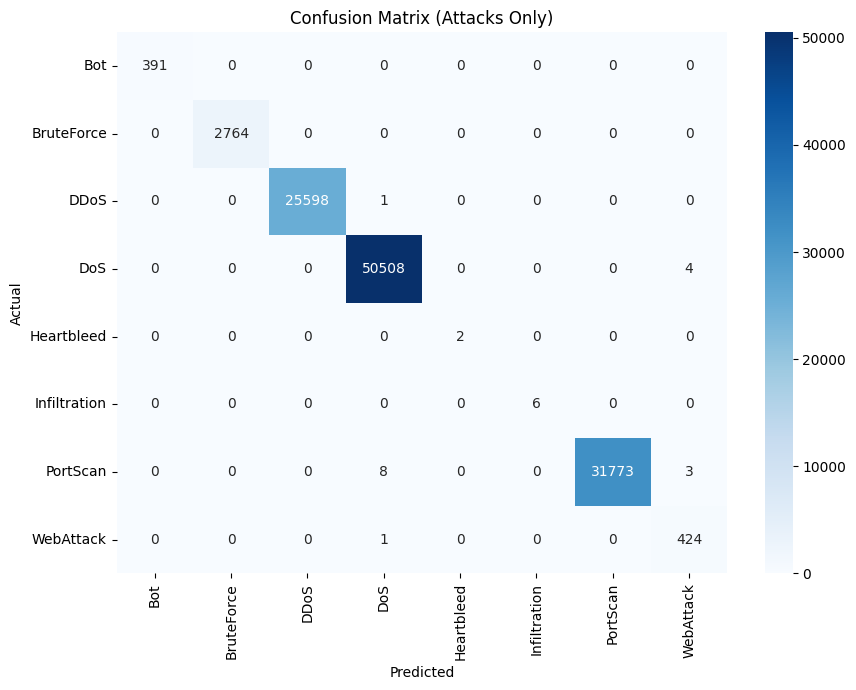

In [37]:
cm_attack = confusion_matrix(
    y_test_attack,
    y_pred_attack,
    labels=attack_labels
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_attack,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=attack_class_names,
    yticklabels=attack_class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Attacks Only)")
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import pandas as pd

unique_labels, counts = np.unique(y_test, return_counts=True)

test_shape_df = pd.DataFrame({
    "Class_Label": unique_labels,
    "Class_Name": [class_names[i] for i in unique_labels],
    "Test_Samples": counts
})

print(test_shape_df)


   Class_Label    Class_Name  Test_Samples
0            0        BENIGN        454620
1            1           Bot           393
2            2    BruteForce          2767
3            3          DDoS         25606
4            4           DoS         50532
5            5    Heartbleed             2
6            6  Infiltration             7
7            7      PortScan         31786
8            8     WebAttack           436
